## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## Импорт библиотек


In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [2]:
def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    # Задание числа пикселей на дюйм
    plt.figure(dpi=100)

    # Предсказание енкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0,],predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение. Без него рисунок не отрисуется
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():
  # Получение названий всех картинок
  paths = glob.glob('*.jpg')

  # Удаление всех картинок по полученным путям
  for p in paths:
    os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [4]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Нормировка
X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

In [6]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

## Создание модели и обучение

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

X_train_torch = torch.tensor(X_train, dtype=torch.float32)

X_train_torch = X_train_torch.permute(0, 3, 1, 2)

train_dataset = TensorDataset(X_train_torch, X_train_torch)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

cuda


In [8]:
# Создание класса автокодировщика
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # ENCODER: сверточная часть
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)    # 14 -> 7
        )
        # ENCODER: полносвязная часть
        self.encoder_fc = nn.Sequential(
            # Преобразует тензор 64x7x7 в одномерный вектор
            nn.Flatten(),

            # Сжатие признаков
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 2)   # 2-мерное скрытое пространство
        )
        # DECODER
        self.decoder_fc = nn.Sequential(

            nn.Linear(2, 128),
            nn.ReLU(),

            # Возвращаем размерность к 64*7*7
            nn.Linear(128, 64 * 7 * 7),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(

            # Преобразуем вектор обратно в тензор 64x7x7
            nn.Unflatten(1, (64, 7, 7)),

            # Увеличение изображения:
            # 7x7 -> 14x14
            nn.ConvTranspose2d(
                64,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Увеличение изображения:
            # 14x14 -> 28x28
            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),


            # 32 карты признаков - 1 канал изображения
            nn.Conv2d(32, 1, kernel_size=3, padding=1),


            nn.Sigmoid()
        )
    # получаем 2D скрытое пространство
    def encode(self, x):

        # Сжатие изображения в 2 числа
        x = self.encoder_conv(x)
        # Начало восстановления из 2 чисел
        z = self.encoder_fc(x)

        return z

    def forward(self, x):
        # Сжатие изображения в 2 числа
        z = self.encode(x)
        # Начало восстановления из 2 чисел
        x = self.decoder_fc(z)
        # Восстановление изображения 28x28
        x = self.decoder_conv(x)
        return x

In [9]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

ЭПОХА: 1, loss: 0.066741


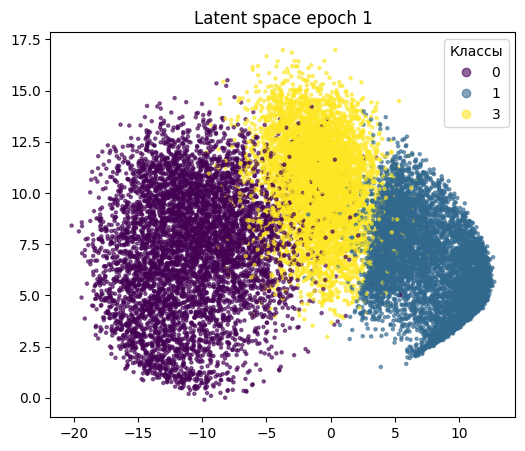

ЭПОХА: 2, loss: 0.036788


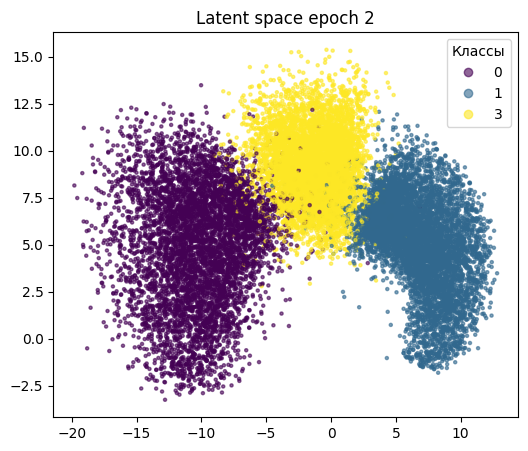

ЭПОХА: 3, loss: 0.033741


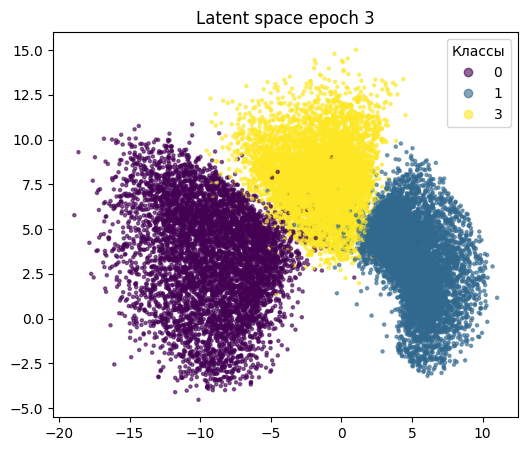

ЭПОХА: 4, loss: 0.032004


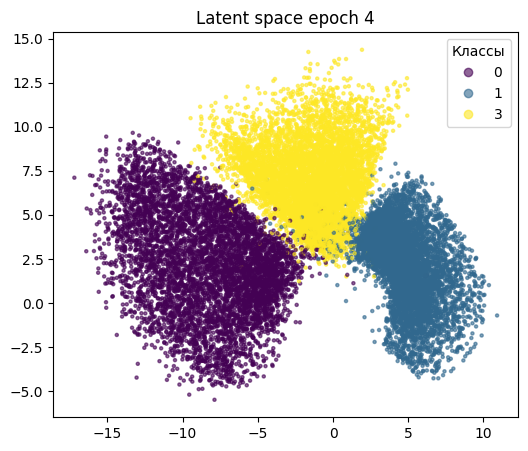

ЭПОХА: 5, loss: 0.030758


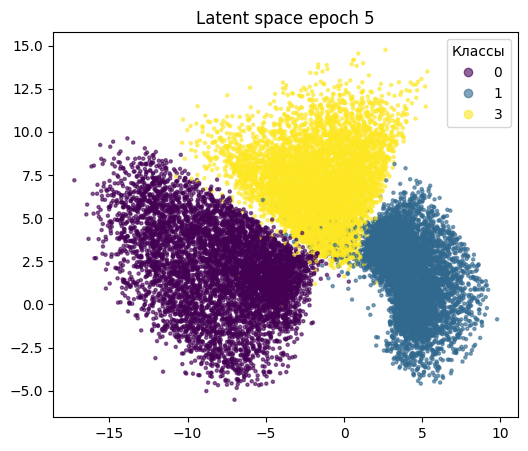

ЭПОХА: 6, loss: 0.030079


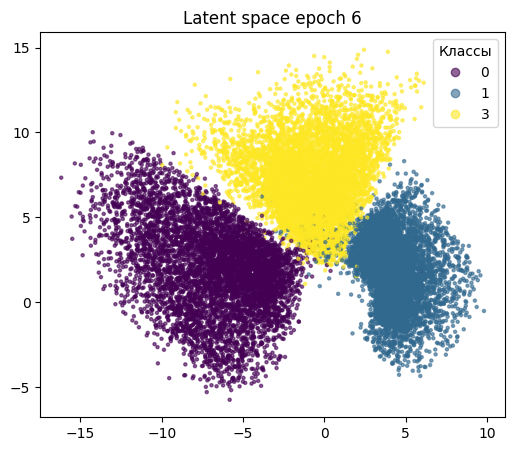

ЭПОХА: 7, loss: 0.029716


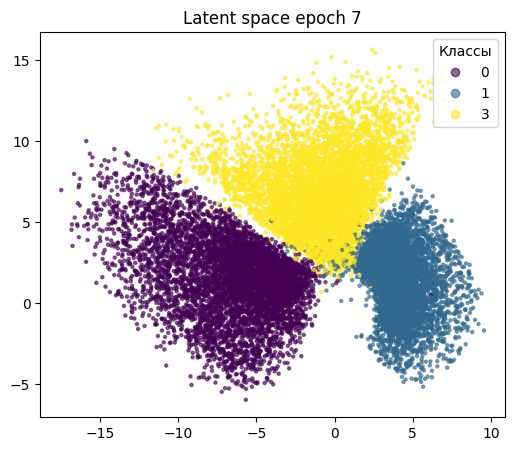

ЭПОХА: 8, loss: 0.029134


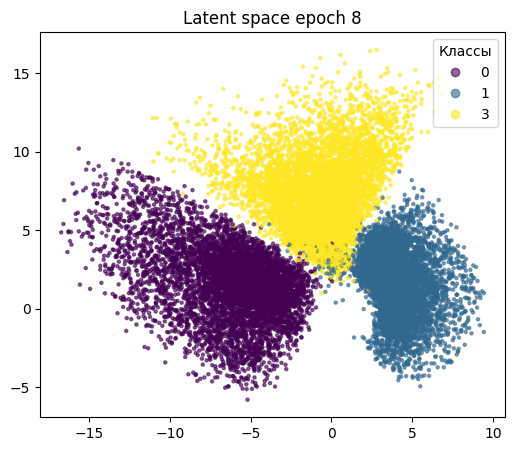

ЭПОХА: 9, loss: 0.028962


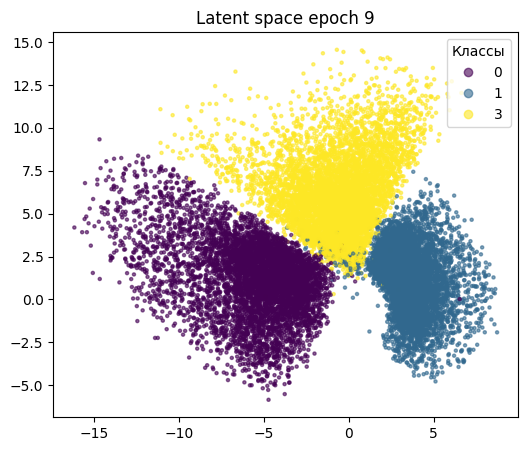

ЭПОХА: 10, loss: 0.028687


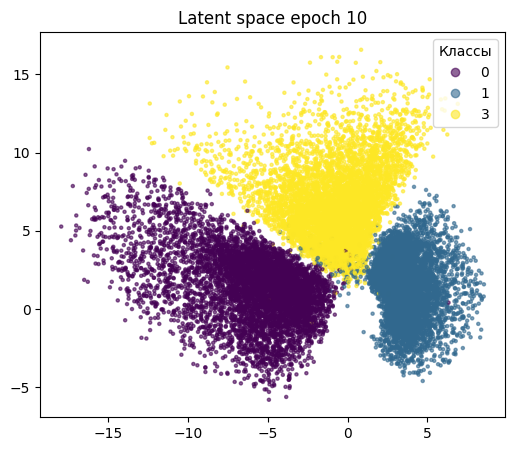

In [10]:
loss_history = []

for epoch in range(10):
    # Перевод модели в режим обучения
    # включает BatchNorm и другие обучаемые слои
    model.train()
     # Суммарная ошибка за эпоху
    total_loss = 0
    # Проход по всем батчам обучающей выборки
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        # Обнуление предыдущих градиентов
        optimizer.zero_grad()
        # изображение -> encoder -> decoder -> восстановленное изображение
        outputs = model(x_batch)

        loss = criterion(outputs, x_batch)
        # Вычисление градиентов
        loss.backward()
        # Обновление весов нейросети
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)

    print(f"ЭПОХА: {epoch + 1}, loss: {epoch_loss:.6f}")

    # Визуализация 2D скрытого пространства
    model.eval()
    with torch.no_grad():
        z = model.encode(X_train_torch.to(device)).cpu().numpy()

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=y_train, alpha=0.6, s=5)
    plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')
    plt.title(f'Latent space epoch {epoch + 1}')
    plt.show()

In [11]:
final_mse = loss_history[-1]
print("Final MSE:", final_mse)

Final MSE: 0.028687084461937917
